# Offline activities module II

## DISCLAIMER:
**Task 1 and 2 are what I've done because I misunderstood last time's tasks and worked out functions for sensitivity and representativity.**

### Task I
After lecture 3 (March 20th), please think about how to define representativity and selectivity mathematically, and read about the Gini Index and Shannon Entropy.After lecture 3 (March 20th), please think about how to define representativity and selectivity mathematically, and read about the Gini Index and Shannon Entropy.\
\
Our data for a screen can be represented as a two-dimensional matrix of dose response curves with compounds and targets being the dimensions of the matrix. Representativity describes how many compounds one compound can represent, i.e. how generalisable a compound is. Selectivity, on the other hand, describes how specific a compound is for a target. This is to say a compound responding to many targets is not very selective meanwhile a compound only responding to one or a few targets is very selective. As hinted at by you the Gini index or the Shannon entropy are possible measures of selectivity.

#### Gini index
A measure of inequality (originally income inequality) among a set of values. A set with a theoretical perfectly equal distribution of wealth or value would have an index of 0 and a set where one value holds all the wealth/value would have an index of 1.\
The index is calculated by sorting the set by ascending values and then then plotting the cumulative share curve of the values as a fraction of the total share (0 to 1). A "perfect equality" line is drawn (which would be if the cumulative share of the total value held by the set was equally distributed between the values leading to a 45° straight line). The index is then determined by dividing the area between the straight line and the curve described by the value distribution by the total area below the straight line (0.5).
#### Shannon entropy
The Shannon entropy measures the expected amount of information needed to describe the state of a variable given the probability of each possible outcome of said variable to occur. The more unlikely an event is, i.e. the more potential outcomes it has, the higher the Shannon entropy. Conversely, the likelier an event is, i.e. if there are very few potential outcomes, the lower the Shannon entropy (with the extreme case being 0). The following formula describes the Shannon entropy:\
$$H(X) = -\sum_{i=1}^n p(x_i)*log(p(x_i))$$

In [1]:
import numpy as np

In [84]:
def selectivity(array, method):
    """
    This function computes a measure of selectivity for each compound of an array. The array should
    have an entry (list) for each compound with the dissociation constant to each target for this
    compound. The output is a number between 0 and 1 for each compound. A 1 can be interpreted as a
    perfectly selective compound while a 0 would be a compound which is not selective at all.
    
    Parameters
    ----------
    array
        A 2D array with all dissociation constants for each compound to each target.
    method
        The method used to compute the measure of selectivity. The keywords 'gini' and 'shannon' are
        accepted.
    """
    compound_selectivity = []
    if method == 'gini':
        for compound in array:
            # calculate the inverse of each value (lower Kd, higher affinity)
            for a in range(len(compound)):
                compound[a] = 1/compound[a]
            # sort responses ascending
            compound.sort()
            if all(a == 0 for a in compound):
                compound_selectivity.append('no targets')
                continue
            # compute the area between the Lorenz curve and the 45 degree equality line.
            lorenz_area, cumulative_share = 0, 0
            for response in range(len(compound)):
                cumulative_share += compound[response]/sum(compound)
                lorenz_area += (((response+1)/len(compound)) - cumulative_share)*(1/len(compound))
            # Correction in the extreme case where only one target is targeted
            if lorenz_area == (len(compound)-1)/(len(compound)*2):
                lorenz_area += 1/(2*len(compound))
            # Using the area, compute the gini index for this compound
            compound_selectivity.append(round(lorenz_area/0.5,3))
                
    elif method == 'shannon':
        # calculate the inverse of each value (lower Kd, higher affinity)    
        inverse = []
        for compound in array:
            comp = []
            for a in compound:
                comp.append(1/a)
            inverse.append(comp)
        # Calculate the probability for the binding of a specific target by a compound
        probabilities = []
        for compound in inverse:
            comp = []
            affinitysum = sum(compound)
            for a in compound:
                comp.append(a/affinitysum)
            probabilities.append(comp)
        # Compute the shannon entropy for each compound
        for compound in probabilities:
            entropy = 0
            for prob in compound:
                entropy += prob * np.log(prob)
            shannonselectivity = 1 - (-entropy)/np.log(len(compound))
            compound_selectivity.append(float(shannonselectivity))
    return compound_selectivity

In [11]:
def representativity(array, var=0.1, threshold=0.9):
    """
    This function computes a measure of representativity for each compound of an array. The array
    should have an entry (list) for each compound with the dissociation constant to each target
    for this compound. The output is a number between 0 and 1 for each compound. A 1 can be
    interpreted as a perfectly selective compound while a 0 would be a compound which is not
    selective at all.
    
    Parameters
    ----------
    array
        A 2D array with all dissociation constants for each compound to each target.
    var
        How much a value may differ from another expressed as a fraction.
    threshold
        The threshold for similarity between two vectors.
    """
    compound_rep, similarity = [], []
    # Calculate the similarity between each compound vector
    for compound in range(len(array)):
        simline, ref = [], array[compound]
        for comp in array[compound:]:
            simsum = 0
            for x in range(len(ref)):
                if comp[x] >= (1-var)*ref[x] and comp[x] <= (1+var)*ref[x]:
                    simsum += 1
            simline.append(simsum/len(ref))
        similarity.append(simline)
    # Complete the symmetry of the matrix
    completed_sim = []
    for vect in range(len(similarity)):
        newvect = list(similarity[vect])
        for x in range(vect):
            newvect.insert(x,similarity[x][vect-x])
        completed_sim.append(newvect)
    
    # Calculate the representativity using a set threshold for similarity
    for a in range(len(completed_sim)):
        calc_vect, sumsim = completed_sim[a], 0
        for b in range(len(calc_vect)):
            if b != a and calc_vect[b] >= threshold:
                sumsim += 1
        compound_rep.append(round(sumsim/(len(completed_sim[a])-1),3))
    
    return compound_rep

### Task II
Read this review before the next lecture on March 27th: Vincent, Fabien, and Davide Gianni. “The Limitations of Small Molecule and Genetic Screening in Phenotypic Drug Discovery.”, Cell Chemical Biology (2025).\
\
How are compounds pooled and yet identified specifically? Are they tested separately if there is a hit?
How would photoreactive compounds be used as drugs? Shining lasers at the target sites? Does this open up the opportunity for targeted medication for highly specific tissues and places in the body? It's likely best to use both types of screens to increase the drug search space and reduce shortcomings of both methods.

### Task III
Use a literature programming tool of your own choice, for instance Jupyter Notebook, R Markdown, or Quarto, to write a short tutorial about factor analysis, including a use case of your own choice. The goal is to explain the concept of factor analysis to others who have not heard about or used it, and to demonstrate how to do it. Submit your document to a GitHub/GitLab repo, and submit the link to your repository here via Google Form.

To explain it very simply, a factor analysis is the breakdown of very complex data into smaller information bits for individual parameters which are grouped by coherence into factors (e.g., shape is composed of length, width, height, volume, surface area, granularity, etc.). The analysis first extracts individual parameters from complex data and then reduces the data size by linearily adding a group of parameters into one factor (number) for each cell thereby reducing the number of data points per cell (i.e. reducing the dimensions of the dataset). The data is compressed, therefore also more manageable, and more interpretable.

In [1]:
import pandas as pd
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
import numpy as np
import random

In [11]:
"""
As an example, we'll look at spatial transcriptomics data of zebrafish. This dataset will have the spatial information
for each cell, and by proxy each gene, and the expression levels of many different genes including housekeeping genes, cell
type specific genes, and microbiome genes. We'll perform a factor analysis on a hypothetical nonexistent dataset with only a
few cells to simplify the example.
"""
# Creating a hypothetical dataset
prepdict = {}
coord = []
for cell in range(500):
    z = cell // 5
    if z < 10:
        x,y = random.randint(-3,3), random.randint(-4,4)
    elif z < 30:
        x,y = random.randint(-5,5), random.randint(-6,7)
    elif z < 50:
        x,y = random.randint(-5,5), random.randint(-6,14)
    elif z < 70:
        x,y = random.randint(-8,8), random.randint(-6,7)
    elif z < 90:
        x,y = random.randint(-4,4), random.randint(-4,4)
    elif z < 100:
        x,y = random.randint(-2,2), random.randint(-10,10)
    coord.append([x,y,z])
xl,yl,zl = [],[],[]
for n in coord:
    xl.append(n[0])
    yl.append(n[1])
    zl.append(n[2])
prepdict['x'],prepdict['y'],prepdict['z'] = xl, yl, zl
for x in range(1,101):
    gene = 'gene ' + str(x)
    exp = []
    bodypart = random.choice([[0,49],[50,149],[150,249],[250,349],[350, 449],[450,499]])
    for n in range(500):
        if x <= 25:
            # housekeeping genes
            exp.append(random.randint(8,50))
        elif x <= 45:
            # microbiome genes
            if n >= 150 and n < 350:
                exp.append(random.randint(5,20))
            else:
                exp.append(random.randint(0,1))
        elif x <= 55:
            # fin genes
            if (n >= 150 and n < 350) or (n >= 450):
                exp.append(random.randint(20,50))
            else:
                exp.append(random.randint(0,1))
        else:
            # tissue specific genes
            if n >= bodypart[0] and n <= bodypart[1]:
                exp.append(random.randint(10,40))
            else:
                exp.append(random.randint(0,3))
    prepdict[gene] = exp
df = pd.DataFrame(prepdict)

In [39]:
# Develop a model; we can choose as many factors as we want theoretically, but since we want to reduce
# the dimensionality of our dataframe we should choose as few as possible.

threefactoranalysis = FactorAnalysis(n_components=3)
factorstranscriptomics = threefactoranalysis.fit_transform(df)

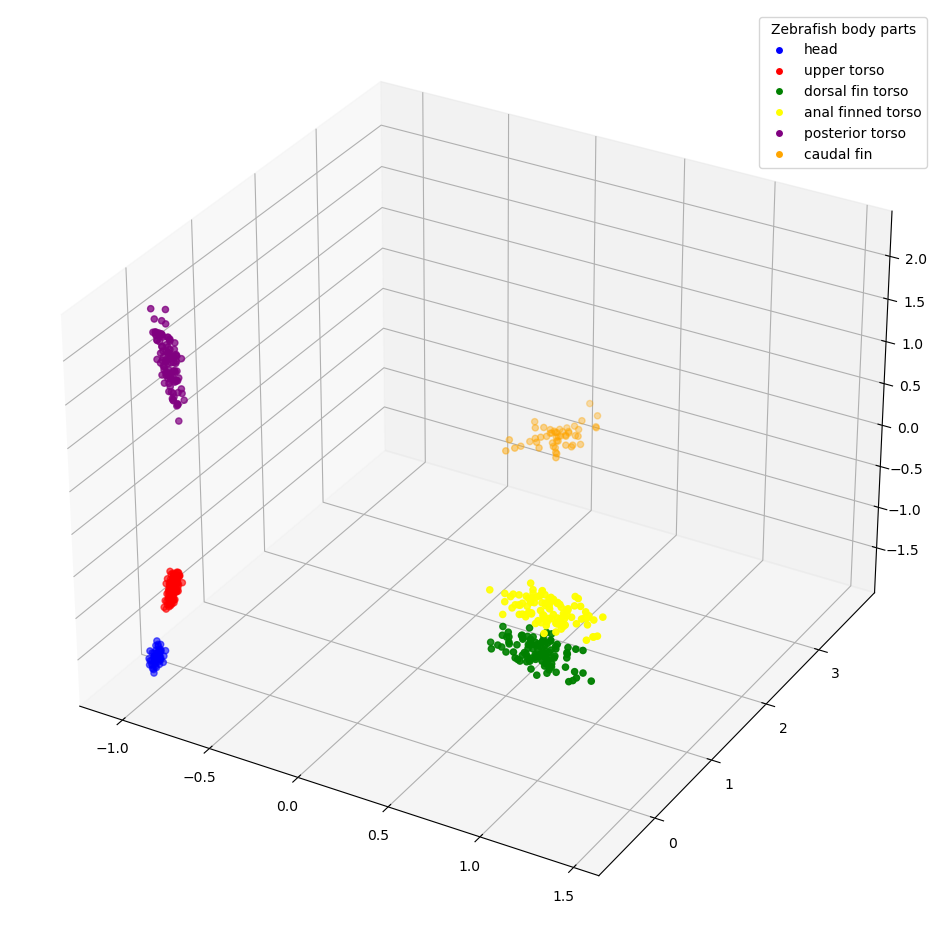

In [53]:
# Finally, let's visualise the analysis. Colours are assigned based on body part.
bodp = []
for x in range(500):
    if x < 50:
        bodp.append(0)
    elif x < 150:
        bodp.append(1)
    elif x < 250:
        bodp.append(2)
    elif x < 350:
        bodp.append(3)
    elif x < 450:
        bodp.append(4)
    elif x < 500:
        bodp.append(5)
colchoice = np.array(bodp,dtype=np.int8)
colours = np.array(['blue','red','green','yellow','purple','orange'])

# Plotting
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.scatter(factorstranscriptomics[:,0], factorstranscriptomics[:,1], factorstranscriptomics[:,2], c=colours[colchoice])
labels=['head', 'upper torso', 'dorsal fin torso', 'anal finned torso', 'posterior torso', 'caudal fin']
handles = [plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=colours[i]) for i in range(len(labels))]
ax.legend(handles=handles, labels=labels, title='Zebrafish body parts')
plt.show()